In [13]:
import os
from dotenv import load_dotenv
import pandas as pd

In [14]:
load_dotenv()

True

In [15]:
pd.options.display.max_columns=False
df = pd.read_csv(os.getenv('cleaned_csv_path'))

In [16]:
df

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,161427,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088
1,223440,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459
2,208267,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443
3,161933,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775
4,167973,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950
...,...,...,...,...,...,...,...,...,...,...
95832,174800,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107
95833,265846,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066
95834,82500,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619
95835,185250,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696


In [22]:
# from sklearn.model_selection import train_test_split

# X_train, X_test = train_test_split(df, test_size=0.2)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
inertia = []

K = range(2, 100)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

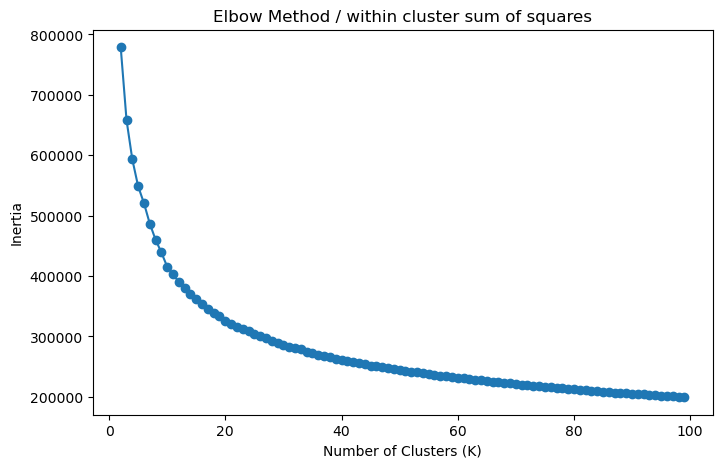

In [29]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method / within cluster sum of squares")

plt.show()

In [30]:
silhouette_scores = []

for k in range(60,61):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 60, Silhouette Score = 0.1079
